In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/credit-screening/crx.data"
df = pd.read_csv(url, header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,00202,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,00043,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,00280,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,00100,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,00120,0,+


In [ ]:
df.columns = ["Gender", "Age", "Debt", "Married", "BankCustomer", "EducationLevel", "Ethnicity", "YearsEmployed", "PriorDefault", "Employed", "CreditScore", "DriversLicense", "Citizen", "ZipCode", "Income", "Approved"]
df.head()

,Gender,Age,Debt,Married,BankCustomer,EducationLevel,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,Approved
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,00202,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,00043,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,00280,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,00100,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,00120,0,+


In [ ]:
print("Shape of dataset:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

Shape of dataset: (690, 16)

Data types:
 Gender             object
Age                object
Debt              float64
Married            object
BankCustomer       object
EducationLevel     object
Ethnicity          object
YearsEmployed     float64
PriorDefault       object
Employed           object
CreditScore         int64
DriversLicense     object
Citizen            object
ZipCode            object
Income              int64
Approved           object
dtype: object

Missing values:
 Gender            0
Age               0
Debt              0
Married           0
BankCustomer      0
EducationLevel    0
Ethnicity         0
YearsEmployed     0
PriorDefault      0
Employed          0
CreditScore       0
DriversLicense    0
Citizen           0
ZipCode           0
Income            0
Approved          0
dtype: int64


In [ ]:
df.isin(["?"]).sum()

,0
Gender,12
Age,12
Debt,0
Married,6
BankCustomer,6
EducationLevel,9
Ethnicity,9
YearsEmployed,0
PriorDefault,0
Employed,0


In [ ]:
df = df.replace("?", np.nan)
df.isnull().sum()

,0
Gender,12
Age,12
Debt,0
Married,6
BankCustomer,6
EducationLevel,9
Ethnicity,9
YearsEmployed,0
PriorDefault,0
Employed,0


In [ ]:
df["Age"] = df["Age"].astype(float)
for col in ["Gender", "Married", "BankCustomer", "EducationLevel", "Ethnicity", "ZipCode"]: df[col] = df[col].fillna(df[col].mode()[0])
df.isnull().sum()

,0
Gender,0
Age,0
Debt,0
Married,0
BankCustomer,0
EducationLevel,0
Ethnicity,0
YearsEmployed,0
PriorDefault,0
Employed,0


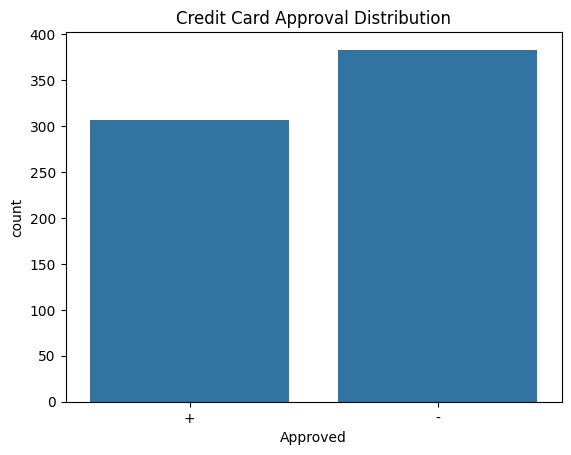

In [ ]:
sns.countplot(x="Approved", data=df)
plt.title("Credit Card Approval Distribution")
plt.show()

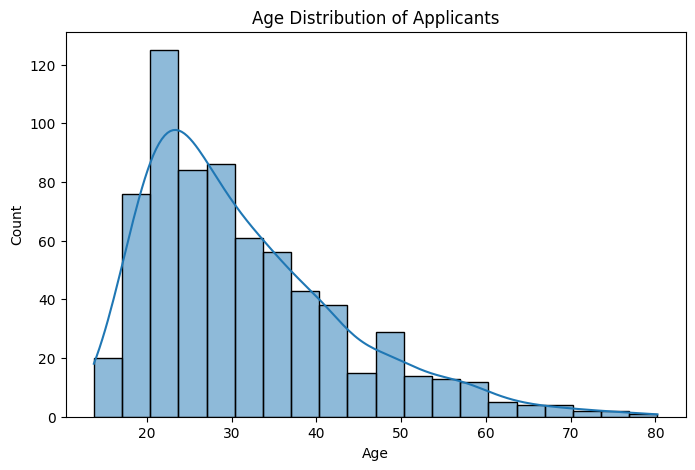

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution of Applicants")
plt.xlabel("Age")
plt.show()

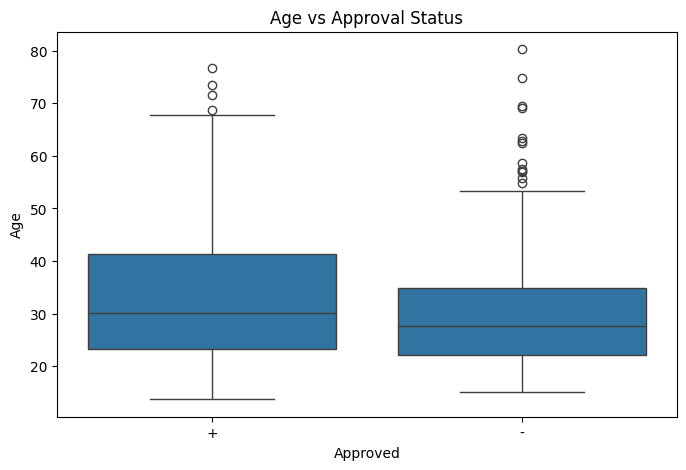

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Approved", y="Age", data=df)
plt.title("Age vs Approval Status")
plt.show()

In [ ]:
for col in df.columns:
      if df[col].dtype == "object":
              print(col, ":", df[col].unique())

Gender : ['b' 'a']
Married : ['u' 'y' 'l']
BankCustomer : ['g' 'p' 'gg']
EducationLevel : ['w' 'q' 'm' 'r' 'cc' 'k' 'c' 'd' 'x' 'i' 'e' 'aa' 'ff' 'j']
Ethnicity : ['v' 'h' 'bb' 'ff' 'j' 'z' 'o' 'dd' 'n']
PriorDefault : ['t' 'f']
Employed : ['t' 'f']
DriversLicense : ['f' 't']
Citizen : ['g' 's' 'p']
ZipCode : ['00202' '00043' '00280' '00100' '00120' '00360' '00164' '00080' '00180'
 '00052' '00128' '00260' '00000' '00320' '00396' '00096' '00200' '00300'
 '00145' '00500' '00168' '00434' '00583' '00030' '00240' '00070' '00455'
 '00311' '00216' '00491' '00400' '00239' '00160' '00711' '00250' '00520'
 '00515' '00420' '00980' '00443' '00140' '00094' '00368' '00288' '00928'
 '00188' '00112' '00171' '00268' '00167' '00075' '00152' '00176' '00329'
 '00212' '00410' '00274' '00375' '00408' '00350' '00204' '00040' '00181'
 '00399' '00440' '00093' '00060' '00395' '00393' '00021' '00029' '00102'
 '00431' '00370' '00024' '00020' '00129' '00510' '00195' '00144' '00380'
 '00049' '00050' '00381' '00150'

In [ ]:
df = df.drop("ZipCode", axis=1)

In [ ]:
from sklearn.preprocessing import LabelEncoder; le = LabelEncoder(); [df.__setitem__(col, le.fit_transform(df[col])) for col in df.columns if df[col].dtype == "object"]; df.head()

,Gender,Age,Debt,Married,BankCustomer,EducationLevel,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,Income,Approved
0,1,30.83,0.000,1,0,12,7,1.25,1,1,1,0,0,0,0
1,0,58.67,4.460,1,0,10,3,3.04,1,1,6,0,0,560,0
2,0,24.50,0.500,1,0,10,3,1.50,1,0,0,0,0,824,0
3,1,27.83,1.540,1,0,12,7,3.75,1,1,5,1,0,3,0
4,1,20.17,5.625,1,0,12,7,1.71,1,0,0,0,2,0,0


In [ ]:
X = df.drop("Approved", axis=1); y = df["Approved"]; print(X.shape, y.shape)

(690, 14) (690,)


In [ ]:
from sklearn.model_selection import train_test_split; X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42); print(X_train.shape, X_test.shape)

(552, 14) (138, 14)


In [ ]:
from sklearn.preprocessing import StandardScaler; scaler = StandardScaler(); X_train_scaled = scaler.fit_transform(X_train); X_test_scaled = scaler.transform(X_test); print(X_train_scaled[:2])

[[ 0.65295987 -0.58195732  1.8520771   1.74053953  1.74682015 -0.1732373
  -1.25311171 -0.70123581 -1.02569226 -0.86739896 -0.49503255 -0.90984316
  -0.30540251 -0.19236401]
 [ 0.65295987 -0.19132987 -0.22996579 -0.56348402 -0.5738651   1.46742186
   0.74491736  0.49708679  0.9749513   1.15287203  0.12366473  1.09909053
  -0.30540251 -0.19236401]]


In [ ]:
from sklearn.linear_model import LogisticRegression; model = LogisticRegression(); model.fit(X_train_scaled, y_train); print("Model trained successfully!")

Model trained successfully!


In [ ]:
y_pred = model.predict(X_test_scaled); print(y_pred[:10]); print(list(y_test[:10]))

[1 0 1 1 1 1 1 0 1 1]
[1, 0, 1, 1, 0, 0, 1, 0, 1, 1]


In [ ]:
from sklearn.metrics import accuracy_score; acc = accuracy_score(y_test, y_pred); print("Accuracy:", round(acc*100, 2), "%")

Accuracy: 84.06 %


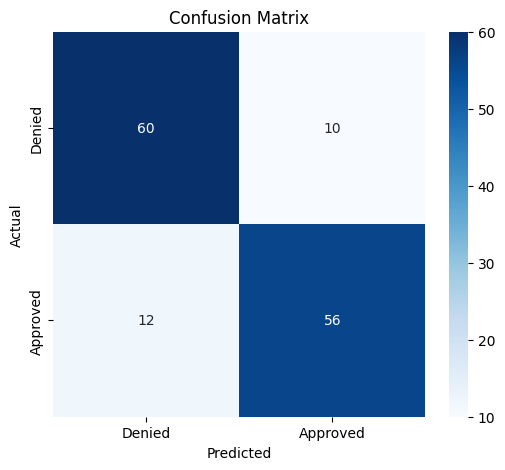

In [ ]:
from sklearn.metrics import confusion_matrix; cm = confusion_matrix(y_test, y_pred); plt.figure(figsize=(6,5)); sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Denied","Approved"], yticklabels=["Denied","Approved"]); plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix"); plt.show()

In [ ]:
from sklearn.metrics import classification_report; print(classification_report(y_test, y_pred, target_names=["Denied","Approved"]))

              precision    recall  f1-score   support

      Denied       0.83      0.86      0.85        70
    Approved       0.85      0.82      0.84        68

    accuracy                           0.84       138
   macro avg       0.84      0.84      0.84       138
weighted avg       0.84      0.84      0.84       138

